# This is a playground for setting up the sim

In [2]:
import autograd.numpy as np
import tidy3d as td
from autograd.tracer import getval
import matplotlib.pyplot as plt
import tidy3d.web as web

print(td.__version__)

2.10.0rc2


In [21]:
# Material.
nInP = 3.13
nAir = 1.0

# Simulation wavelength.
wl = 1.55  # Central simulation wavelength (um).
bw = .04  # Simulation bandwidth (um).
n_wl = 51  # Number of wavelength points within the bandwidth.

#the parameters that kasra optimized
grating_period = .650 # period of the grating
etch_depth = 0.1 #etching depth in (um)
to_substrate = 1.210 #thickness of the substrate (um)
initial_fill_factor = 0.1 #fill factor initial for apodization
R = 0.03 #the coefficent for the apodization with units of (um^-1)
r0 = 0 #distance to the first tooth from the end of the waveguide (um)

# Geometric parameters.
w_thick = 0.27  # Waveguide thickness (um).
w_width = 0.6  # Waveguide width (um).
w_length = 1.0  # Waveguide length (um).
border_buffer = 0.16 # buffer around the device
N_teeth = 6 # number of teeth in the grating

#fiber output permaters all initial
source_theta = np.deg2rad(10.0) #angle of the fiber output 
mfd = 4 #mode fiber diameter
source_x = 2.9 #x position of the fiber 
src_offset = 0.5  # Distance between the source focus and device (um).

# Material definition.
mat_InP = td.Medium(permittivity=nInP**2)  # Waveguide material.
mat_air = td.Medium(permittivity=nAir**2)  # SiO2 material.

#fabrication parameters
sidewall_angle = 0 #angle of the sidewall
dilation = 0 #dilation of the sidewalls

# Wavelengths and frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])
run_time = 1e-12

# Computational domain size.
pml_spacing = 0.6 * wl
inf_eff = 1000
min_steps_per_wvl = 20

#define the bounds for the parameters
widths_bounds = (0.05, 0.6)
r0_bounds = (0,2)
etch_depth_bounds = (0.05, 0.2)
to_substrate_bounds = (.8,2)

In [22]:
def projection_builder(widths_bounds=widths_bounds, 
    r0_bounds=r0_bounds, 
    etch_depth_bounds=etch_depth_bounds, 
    to_substrate_bounds=to_substrate_bounds,
    N_teeth=N_teeth
):
    """
    This function builds the projection and inverse projection functions for a given set of bounds.
    """
    maxes = np.array([*([widths_bounds[1]]*(N_teeth*2+2)), r0_bounds[1], etch_depth_bounds[1], to_substrate_bounds[1]])
    mins = np.array([*([widths_bounds[0]]*(N_teeth*2+2)), r0_bounds[0], etch_depth_bounds[0], to_substrate_bounds[0]])

    def project(params):
        return 0.5*(maxes-mins)*np.tanh(params)+0.5*(maxes+mins)
    
    def inverse_project(params):
        return np.arctanh((2*params-(maxes+mins))/(maxes-mins))
    
    return project, inverse_project

In [23]:
def get_centers(widths, r0):
    """
    This function takes in a list of widths and returns a list of centers.

    Args:
        widths (list): A list of widths.
        r0 (float): The radius that the grating starts at.

    Returns:
        list: A list of centers.
    """
    centers = []
    for i in range(len(widths)):
        centers.append(r0+np.sum(widths[:i])+widths[i]/2)
    return centers

def apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor, N_teeth=N_teeth, grating_period=grating_period):
    """
    This function take the apodization variables and return a list of widths.

    Args:
        r0 (float): The radius that the grating starts at.
        R (float): The rate of the apodization.
        initial_fill_factor (list): A list of initial fill factors.

    Returns:
        list: A list of widths.
    """
    widths = []
    for i in range(N_teeth+1):
        ff = initial_fill_factor + R * i * grating_period
        widths.append(grating_period * ff)
        widths.append(grating_period * (1-ff))
    return widths

In [24]:

def make_grating_structure(
    widths,
    etch_depth=etch_depth,
    to_substrate=to_substrate,
    r0=r0,
    N_teeth=N_teeth,
    grating_period=grating_period,
    w_thick=w_thick,
    border_buffer=border_buffer,
    sidewall_angle=sidewall_angle,
    dilation=dilation,
):
    """
    This function makes the grating structure.

    Args:
        widths (list): A list of widths.
        etch_depth (float): The etching depth.
        to_substrate (float): The thickness of the substrate.
        r0 (float): The radius that the grating starts at.
        N_teeth (int): The number of teeth in the grating.
        sidewall_angle (float): The angle of the sidewall.
        dilation (float): The dilation of the sidewalls.
    """
    #get the centers of the teeth and gaps
    centers = get_centers(widths, r0)

    #untracked values
    dilation_untracked = float(getval(dilation))
    etch_depth_untracked = float(getval(etch_depth))

    #create the substrate
    substrate = td.Structure(
            geometry=td.Box.from_bounds((-inf_eff,-inf_eff,-inf_eff),(inf_eff,inf_eff,-to_substrate)),
            medium=mat_InP,
            name='substrate')

    #create the waveguide
    bottom_waveguide = td.Structure(
        geometry=td.Box.from_bounds((-inf_eff,-inf_eff,0),
                                    (float(getval(r0))+dilation_untracked,inf_eff,w_thick-etch_depth_untracked)),
        medium=mat_InP,
        name='bottom_waveguide')

    top_waveguide = td.Structure(
        geometry=td.Box.from_bounds((-inf_eff,-inf_eff,w_thick-etch_depth_untracked),
                                    (r0+dilation,inf_eff,w_thick)),
        medium=mat_InP,
        name='top_waveguide')
    
    #create the end waveguide
    top_end_waveguide = td.Structure(
        geometry=td.Box.from_bounds((centers[-1]-widths[-1]/2-dilation,-inf_eff,w_thick-etch_depth_untracked),
                                    (inf_eff,inf_eff,w_thick)),
        medium=mat_InP,
        name='top_end_waveguide')
    bottom_end_waveguide = td.Structure(
        geometry=td.Box.from_bounds((float(getval(centers[-1]))-float(getval(widths[-1]))/2-dilation_untracked,-inf_eff,0),
                                    (inf_eff,inf_eff,w_thick-etch_depth_untracked)),
        medium=mat_InP,
        name='bottom_end_waveguide')

    #get the centers of the teeth and gaps
    teeth = []
    teeth_low = []
    teeth_gap_low = []
    for i, (center, width) in enumerate(zip(centers, widths)):
        center_untracked = float(getval(center))
        width_untracked = float(getval(width))
        if i % 2 == 0:
            tooth_geom_gap_low = td.Box.from_bounds((center_untracked-width_untracked/2-dilation_untracked,-inf_eff,0),
                                                    (center_untracked+width_untracked/2+dilation_untracked,inf_eff,w_thick-etch_depth))
            teeth_gap_low.append(tooth_geom_gap_low)

        if i%2 == 1 and i != len(centers)-1:
            tooth_geom = td.Box.from_bounds((center-width/2-dilation,-inf_eff,w_thick-etch_depth_untracked),
                                            (center+width/2+dilation,inf_eff,w_thick))
            teeth.append(tooth_geom)

            tooth_geom_low = td.Box.from_bounds((center_untracked-width_untracked/2-dilation_untracked,-inf_eff,0),
                                                (center_untracked+width_untracked/2+dilation_untracked,inf_eff,w_thick-etch_depth_untracked))
            teeth_low.append(tooth_geom_low)
            
    teeth = td.Structure(
            geometry=td.GeometryGroup(geometries=teeth),
            medium=mat_InP,
            name='teeth')
    teeth_low = td.Structure(
            geometry=td.GeometryGroup(geometries=teeth_low),
            medium=mat_InP,
            name='teeth_low')
    teeth_gap_low = td.Structure(
            geometry=td.GeometryGroup(geometries=teeth_gap_low),
            medium=mat_InP,
            name='teeth_gap_low')

    #define the minumum and maximum x and z bounds
    min_x = -border_buffer-pml_spacing
    max_x = border_buffer+pml_spacing+getval(centers[-1])+getval(widths[-1])/2+getval(dilation)
    min_z = -border_buffer-pml_spacing-getval(to_substrate)
    max_z = w_thick+border_buffer+pml_spacing

    sim_box = td.Box.from_bounds(
        rmin=(min_x,0,min_z),
        rmax=(max_x,0,max_z),
    )

    structures = [substrate, top_waveguide, bottom_waveguide, teeth, teeth_gap_low, teeth_low, top_end_waveguide, bottom_end_waveguide]
    return structures, sim_box

In [25]:

def make_sim(
    widths,
    etch_depth=etch_depth,
    to_substrate=to_substrate,
    grating_period=grating_period,
    r0=r0,
    N_teeth=N_teeth,
    w_thick=w_thick,
    border_buffer=border_buffer,
    sidewall_angle=sidewall_angle,
    dilation=dilation,
    source_x=source_x,
    source_theta=source_theta,
    mfd=mfd,
    src_offset=src_offset,
    include_field_monitor=False,
    freq=freq,
    freqw=freqw,
    freqs=freqs,
    run_time=run_time,
    pml_spacing=pml_spacing,
    min_steps_per_wvl=min_steps_per_wvl,
):  

    """ 
    This function makes the simulation.
    """

    #get the structures
    structures,sim_box = make_grating_structure(widths,
                etch_depth=etch_depth,
                to_substrate=to_substrate,
                r0=r0,
                N_teeth=N_teeth,
                grating_period=grating_period,
                w_thick=w_thick,
                border_buffer=border_buffer,
                sidewall_angle=sidewall_angle,
                dilation=dilation,
                )
                
    #define the gaussian beam source
    sources = [td.GaussianBeam(
        size=(2 * mfd, inf_eff, 0),
        center=[source_x, 0, w_thick+src_offset],
        source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
        angle_theta=source_theta,
        direction="-",
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2,  # 90 degree polarization angle for TE polarization
        waist_distance=-src_offset,
    )]

    #define the mode monitor
    monitors = [
        td.ModeMonitor(
        center=(-border_buffer, 0, w_thick / 2),
        size=(0, td.inf, w_thick*4),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=nInP),
        name="mode",
    )]

    #if we want to include the field monitor
    if include_field_monitor:
        monitors.append(
            td.FieldMonitor(
                center=(0, 0, 0),
                size=(inf_eff, 0, inf_eff),
                freqs=freq,
                name="field",
            )
        )

    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl),
        structures=structures,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.periodic(),  # set the boundary to periodic in y since it's a 2D simulation
            z=td.Boundary.pml(),
        ),
    )
    return sim

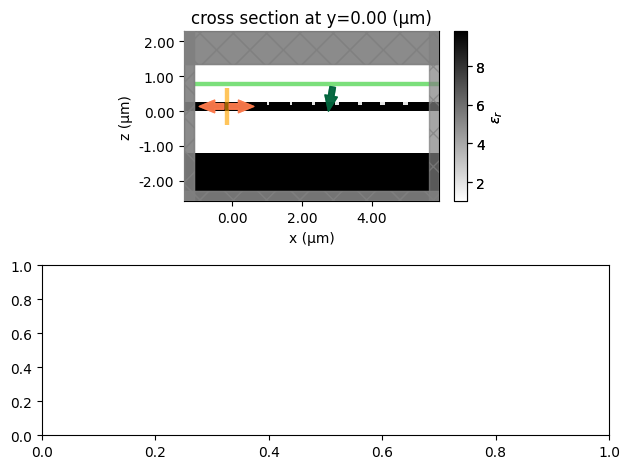

[0.065, 0.5850000000000001, 0.07767500000000001, 0.572325, 0.09035000000000001, 0.55965, 0.103025, 0.546975, 0.1157, 0.5343000000000001, 0.12837500000000002, 0.521625, 0.14105, 0.50895]


In [26]:
widths = apodized_to_widths()
sim1 = make_sim(widths, r0=1, include_field_monitor=False)
sim2 = make_sim(widths, etch_depth=etch_depth-0.01, include_field_monitor=False)

fig,ax = plt.subplots(2,1)
sim1.plot_eps(y=0,ax=ax[0])
sim2.plot_eps(y=0,ax=ax[0],alpha=.1)
plt.tight_layout()
plt.show()
print(widths)

In [34]:
def get_coupling_efficiency(sim_data):
    """
    This function takes in the simulation data and returns the coupling efficiency.
    """
    return np.abs(sim_data["mode"].amps.sel(mode_index=0,direction="-").values)**2

def objective(params):
    sim = make_sim(widths, 
            r0=r0+params[2], 
            etch_depth=etch_depth+params[1], 
            to_substrate=to_substrate+params[0],
            dilation=0+params[3],
            min_steps_per_wvl=50)
    sim_data = web.run(sim, task_name="GC4um_2D_testing", folder_name="dominic", verbose=False)
    return get_coupling_efficiency(sim_data)[n_wl//2]

In [ ]:
from autograd import value_and_grad
params = np.zeros(4)
value, grad = value_and_grad(objective)(params)

In [100]:
print(grad)

[-0.02489258 -0.95199543  0.03631183  3.95544023]


In [101]:
# params = np.zeros(4)
# params[0] += 0.001
# value2 = objective(params)

# params = np.zeros(4)
# params[1] += 0.001
# value3 = objective(params)

params = np.zeros(4)
params[2] += 0.001
value4 = objective(params)

# params = np.zeros(4)
# params[3] += 0.001
# value5 = objective(params)

In [102]:
print((value2-value)/0.001,(value3-value)/0.001,(value4-value)/0.001,(value5-value)/0.001)

-2.0936524111297983 -3.465452442829753 0.0634230303824257 2.0011594726688786


# check the width gradients

In [204]:
project, inverse_project = projection_builder()
def objective(params,projection=project):
    params_proj = projection(params)
    widths = params_proj[:N_teeth*2+2]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate,min_steps_per_wvl=40)
    sim_data = web.run(sim, task_name="GC4um_2D_initial_opt", verbose=False)
    return get_coupling_efficiency(sim_data)[n_wl//2]

In [205]:
widths = apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor)
params0 = np.concatenate([widths, [r0+.001], [etch_depth], [to_substrate]])

value,grad = value_and_grad(objective)(inverse_project(params0))

In [206]:
print(grad)

[-1.03686058e-02  8.46554552e-03 -1.92710824e-02  2.37999459e-02
 -1.77160983e-02  4.20007031e-02  5.63440022e-04  6.46229582e-02
  6.23749645e-02  1.06017579e-01  1.64830483e-01  1.48726682e-01
  2.31023942e-01  1.80819539e-01  2.40554760e-01  1.68864136e-01
  1.77785009e-01  1.28168622e-01  7.84044570e-02  5.60613687e-02
  7.39930787e-03 -1.38882012e-03 -3.06887492e-02 -3.14606894e-02
 -3.65670975e-02 -3.63194802e-02 -2.53506738e-02 -2.46220227e-02
 -1.22598494e-02 -1.20009283e-02 -3.39182475e-05  0.00000000e+00
  7.55908995e-05 -7.01686198e-02 -1.56737433e-02]


In [210]:
grads_numeric = []
for i in range(len(params0)):
    params = inverse_project(params0)
    params[i] += 0.001
    value2 = objective(params)
    grads_numeric.append((value2-value)/0.001)

In [184]:
print((value2-value)/0.0001)

-0.026154149000978677


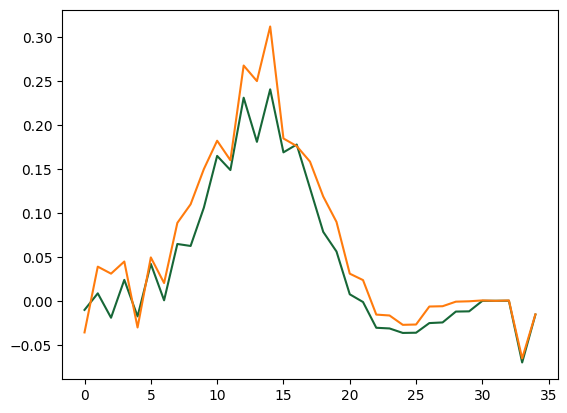

In [211]:
plt.plot(grad)
plt.plot(grads_numeric)
plt.show()

In [17]:
import json
with open('/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_2D/data/stochastic_opt_50nm_6teeth.json', 'r') as f:
    data = json.load(f)

In [35]:
N_teeth=6
def objective(params):
    widths = params[:N_teeth*2+2]
    r0 = params[N_teeth*2+2]
    etch_depth = params[N_teeth*2+3]
    to_substrate = params[N_teeth*2+4]
    
    sim = make_sim(widths, N_teeth=Nteeth, r0=r0, etch_depth=etch_depth, include_field_monitor=True, to_substrate=to_substrate,min_steps_per_wvl=20)
    sim_data = web.run(sim, task_name="GC4um_2D_initial_opt", verbose=False)
    return sim_data,get_coupling_efficiency(sim_data)

In [44]:
widths = apodized_to_widths()
paramsBad = np.hstack([widths,r0,etch_depth,to_substrate])
sim_data2,vals2 = objective(paramsBad)
#sim_data,val = objective(data['params'][-1])

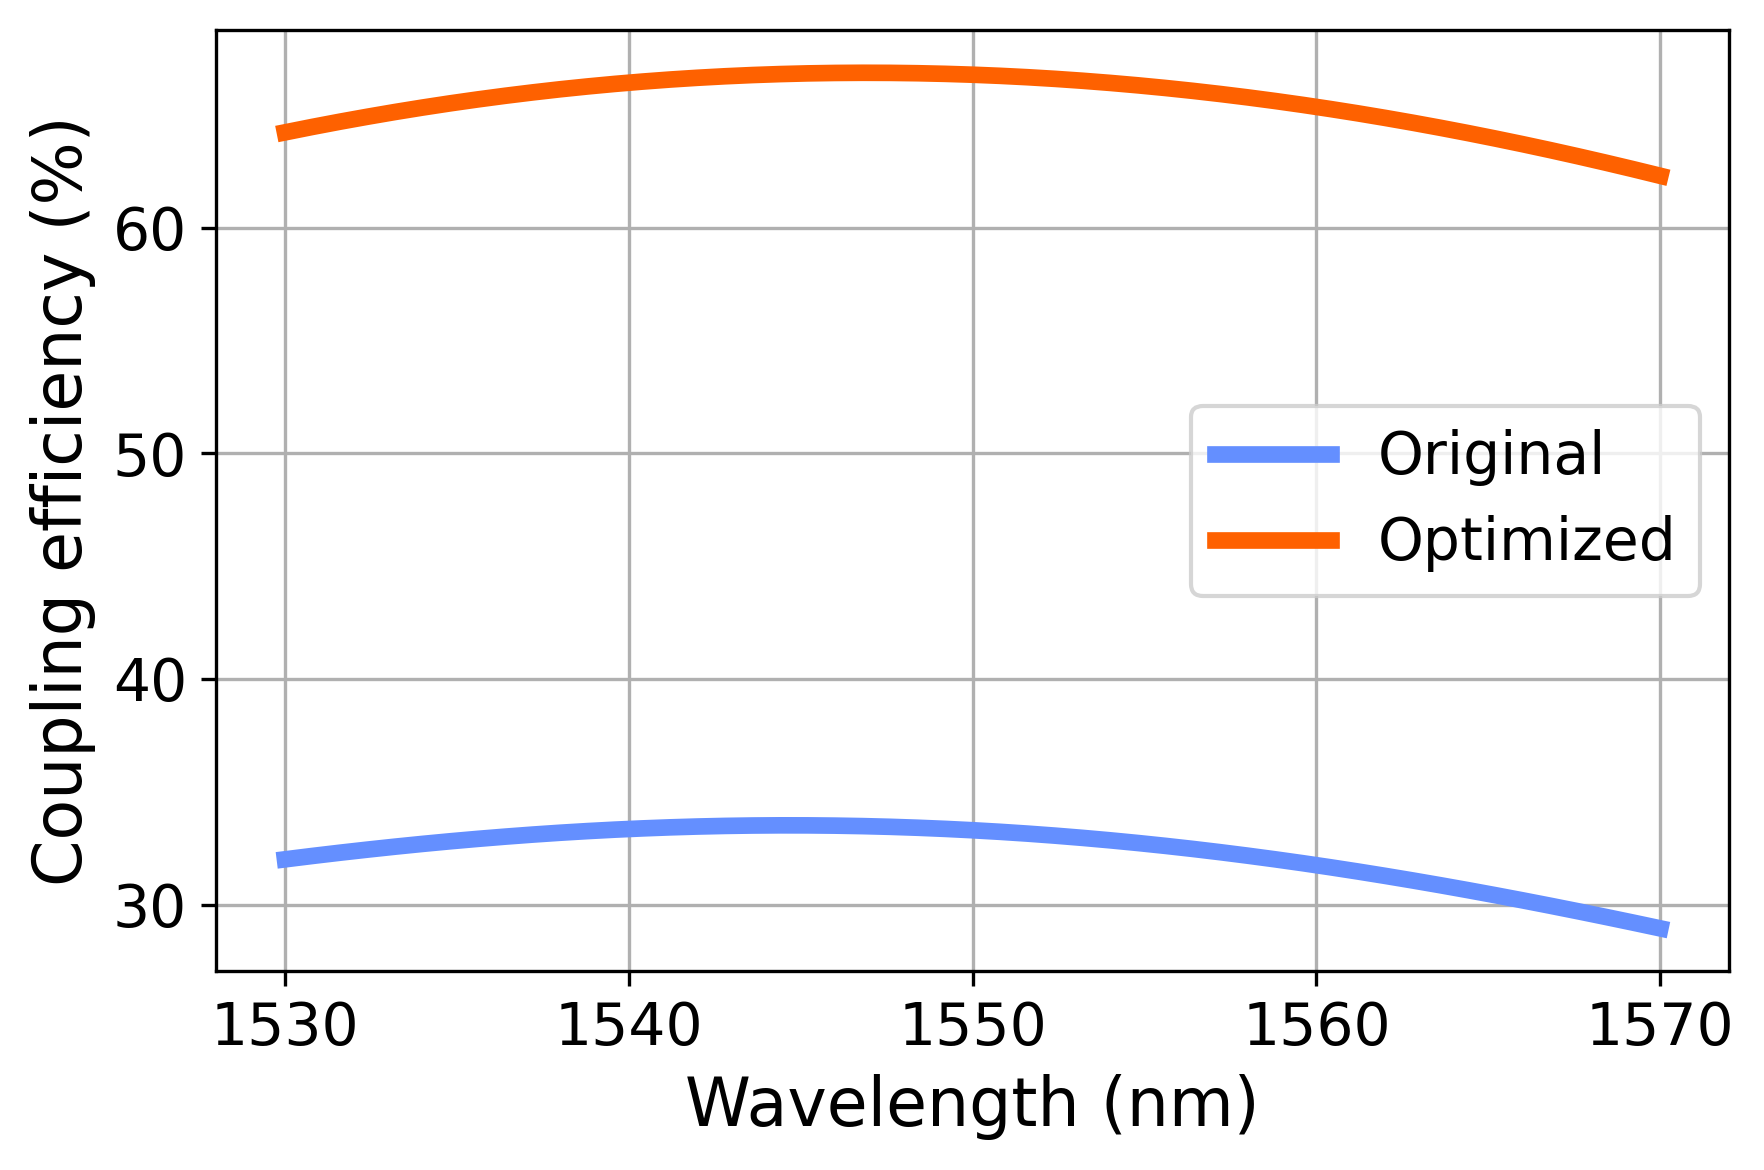

In [45]:
plt.figure(figsize=(6,4),dpi=300)
plt.plot(wl_range*1000, vals2*100, color='#648fff', linewidth=4, label="Original")
plt.plot(wl_range*1000,val*100,color='#fe6100',linewidth=4,label="Optimized")
plt.xlabel('Wavelength (nm)', fontsize=16)
plt.ylabel('Coupling efficiency (%)', fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.grid(True)
plt.show()

<Axes: title={'center': 'cross section at y=0.00 (μm)'}, xlabel='x (μm)', ylabel='z (μm)'>

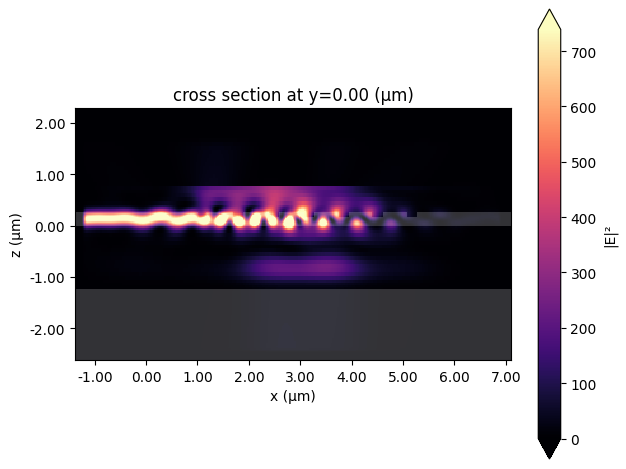

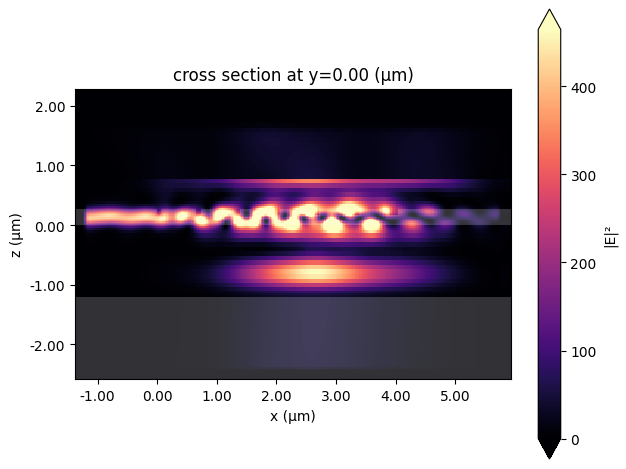

In [48]:
sim_data.plot_field('field','E','abs^2',y=0)
sim_data2.plot_field('field','E','abs^2',y=0)